## Цель работы

Научиться применять модель деревьев решений для задач классификации.

## Задание:

**1 часть - Анализ и визуализация**

+ Подобрать датасет, имеющий отсутствующие значения, категориальные переменные, целевую переменную, принимающую не менее трёх различных значений.
+ Вывести число пропущенных данных. Какую часть от общего объём данных нужно удалить? Удалить строки с отсутствующими значениями.
+ Визулизировать и подготовить данные (как в разобранном на семинаре примере)
---
**2 часть**

+ Разбить данные на обучающий набор и тестовый набор
+ Создать экземпляр классификатора "дерево решений" с параметрами по умолчанию
+ Оценить модель с помощью известных вам метрик
+ Отобразить значимость признаков. Какие самые значимые? Как работает метод расчёта значимостей?
+ Визуализировать граф дерева решений, дать краткую характеристику уровням дерева решений.
+ Обучить модель классификационного решающего дерева с разными ограничениями на глубину, сравнить результаты
+ Уменьшить число листовых узлов, посмотреть точность модели
+ С помощью параметра criterion='entropy' построить и обучить дерево решений, посмотреть оценки модели


# Задание 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('real_drug_dataset.csv')

In [4]:
df.head()

,Patient_ID,Age,Gender,Condition,Drug_Name,Dosage_mg,Treatment_Duration_days,Side_Effects,Improvement_Score
0,P0001,56,Male,Infection,Ciprofloxacin,50,9,Nausea,8.5
1,P0002,69,Male,Hypertension,Metoprolol,500,24,Tiredness,8.7
2,P0003,46,Female,Depression,Bupropion,100,25,Dry mouth,5.4
3,P0004,32,Male,Diabetes,Glipizide,850,44,Low blood sugar,6.4
4,P0005,60,Male,Depression,Bupropion,850,35,Anxiety,5.3


описание датасета

- Patient_ID — уникальный идентификатор пациента

- Age — возраст пациента

- Gender — пол пациента

- Condition — диагностированное заболевание / состояние

- Drug_Name — назначенный лекарственный препарат

- Dosage_mg — дозировка препарата в миллиграммах

- Treatment_Duration_days — длительность курса лечения (в днях)

- Side_Effects — зафиксированные побочные эффекты

- Improvement_Score — числовая оценка улучшения состояния пациента после лечения

целевая - название лекараства drug_name


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   object 
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   Condition                1000 non-null   object 
 4   Drug_Name                1000 non-null   object 
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   object 
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


## Исследование данных

### Отсутствующие значения - Missing Data

ИХ НЕТ В МОЕМ ДАТАСЕТЕ НО ЕСЛИ БЫ ОНИ БЫЛИ ТО НАДО БЫЛО БЫ СДЕЛАТЬ СЛЕДУЮЩЕЕ

In [5]:
df.isna().sum() # возвращает true для ячеек с отсутствующим значением

Patient_ID                 0
Age                        0
Gender                     0
Condition                  0
Drug_Name                  0
Dosage_mg                  0
Treatment_Duration_days    0
Side_Effects               0
Improvement_Score          0
dtype: int64

In [74]:
100*(10/1000) # какой процент данных мы удаляем

1.0

удаляем строки которые содержат хотя бы 1 пропущенное значение

In [ ]:
df = df.dropna()

Проверка структуры данных:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   object 
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   Condition                1000 non-null   object 
 4   Drug_Name                1000 non-null   object 
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   object 
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [ ]:
df.head()

В моем датасете этот шаг фактически не влияет на данные, так как пропусков нет

## Обработка категориальных значений

список уникальных значений в столбце - unique()

In [6]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [7]:
df['Condition'].unique()

array(['Infection', 'Hypertension', 'Depression', 'Diabetes',
       'Pain Relief'], dtype=object)

In [8]:
df['Drug_Name'].unique()

array(['Ciprofloxacin', 'Metoprolol', 'Bupropion', 'Glipizide',
       'Paracetamol', 'Escitalopram', 'Metformin', 'Amlodipine',
       'Ibuprofen', 'Tramadol', 'Azithromycin', 'Sertraline',
       'Insulin Glargine', 'Losartan', 'Amoxicillin'], dtype=object)

In [64]:
df['Drug_Name'].value_counts()

Drug_Name
Tramadol            82
Ciprofloxacin       79
Insulin Glargine    78
Amlodipine          74
Azithromycin        70
Glipizide           67
Bupropion           66
Losartan            66
Amoxicillin         66
Ibuprofen           64
Paracetamol         62
Metformin           62
Escitalopram        55
Sertraline          55
Metoprolol          54
Name: count, dtype: int64

целевая переменная Drug_Name содержит 15 различных классов



## Визуализация

для числовых признаков

<Axes: xlabel='Age', ylabel='Improvement_Score'>

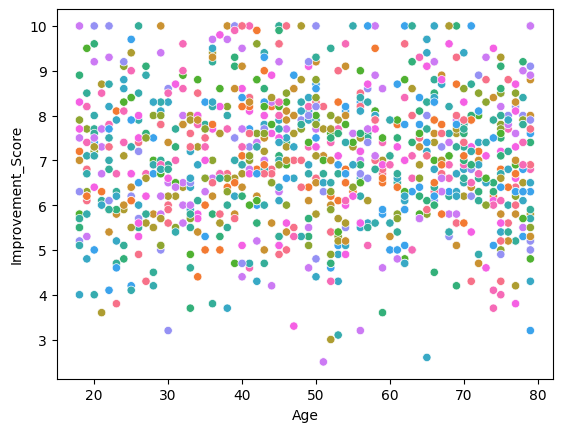

In [76]:
sns.scatterplot(x='Age', y='Improvement_Score', data=df, hue='Drug_Name', legend=False)

Pairplot по целевой переменной

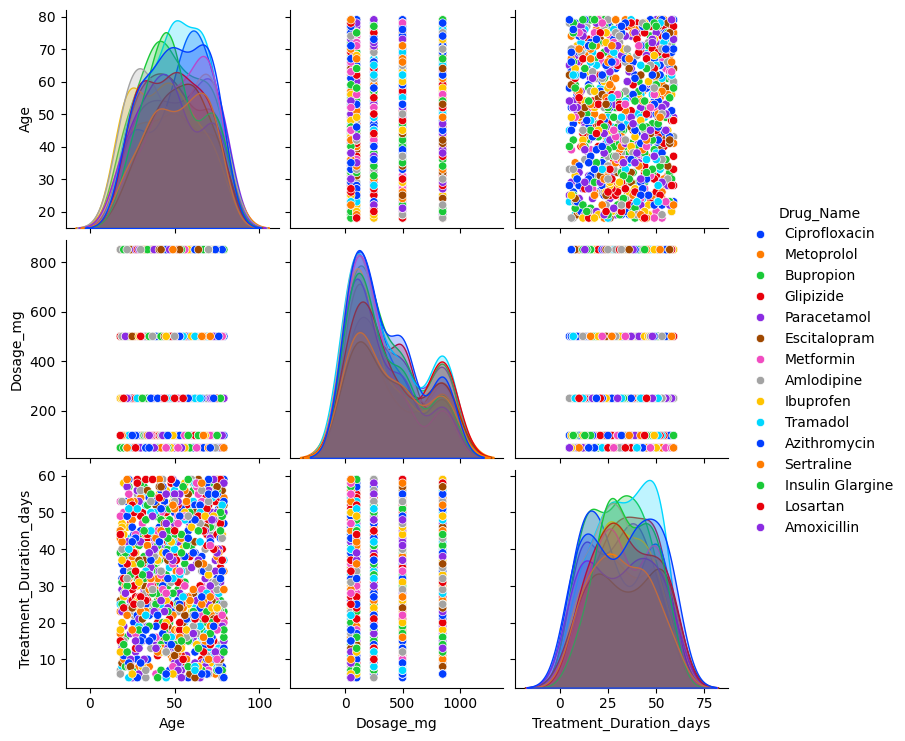

In [61]:
sns.pairplot(df[['Age', 'Dosage_mg','Treatment_Duration_days', 'Drug_Name']], hue='Drug_Name', palette='bright')


На диаграммах рассеяния видно, что возраст пациентов не имеет строгой линейной зависимости от дозировки, однако отдельные препараты характеризуются типичными уровнями доз

В целом данные частично пересекаются между классами, но различия в распределениях дозировок создают предпосылки для классификации препаратов с помощью дерева решений

Catplot - визуализация категориальных данных

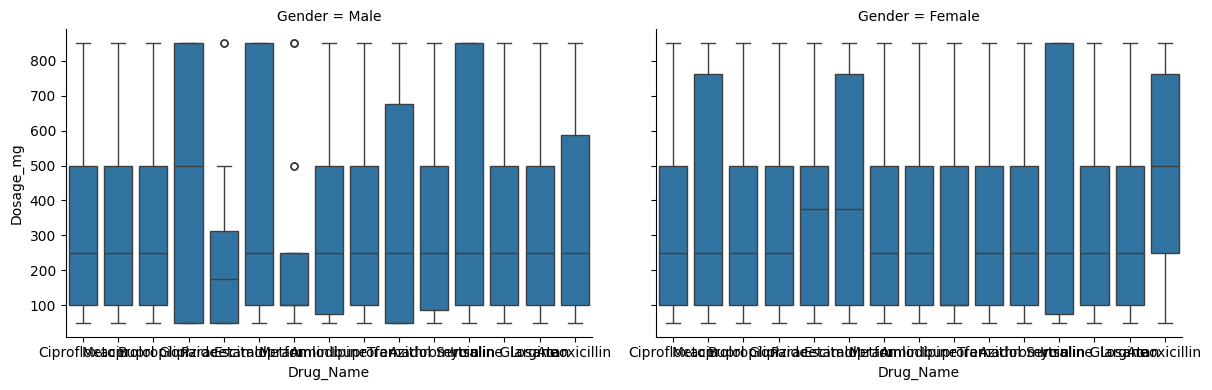

In [42]:
sns.catplot(x='Drug_Name', y='Dosage_mg', data=df, kind='box', col='Gender', col_wrap=2, height=4,aspect=1.5)


Получаем возможность сравнить распределение симптомов между полами для разных заболеваний

Для большинства препаратов диапазоны дозировок у мужчин и женщин схожи, что говорит об отсутствии выраженных половых различий в назначаемых дозах

У ряда препаратов наблюдается широкий разброс доз, что указывает на использование разных стандартных схем лечения или индивидуальный подбор дозировки

----------

## Построение признаков - Feature Engineering

Если применить get_dummies ко всему датафрейму будут закодированы и признаки, и целевая переменная, что не нужно

In [14]:
X = pd.get_dummies(df.drop(['Drug_Name', 'Patient_ID'], axis=1), drop_first=True)

Целевая:

In [15]:
y = df['Drug_Name']

## Разбиение на обучающий и тестовый наборы данных - Train | Test Split

В деревьях решений масштабирование признаков не требуется,
так как в каждом узле используется только один признак

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

В каждом конкретном условии, в каждом конкретном узле будет участвовать только один признак. Поэтому нам не важно, если какой-то признак имеет шкалу значений, существенно отличающуюся от шкалы значений для других признаков.

**можем пропустить шаг масштабирования данных и сразу перейти к разбиению на обучающие тестовые наборы**

**ИТОГО: выполнили исследование данных и подготовку данных, когда исключили некоторые отсутствующие значения.**

# Классификатор "Дерево решений" - Decision Tree Classifier

## Гиперпараметры по умолчанию

Создадим дерево с гиперпараметрами по умолчанию, а также выполним визуализацию дерева.

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
model = DecisionTreeClassifier()

In [20]:
model.fit(X_train,y_train) #обучаем модель на обучающем наборе данных

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Предсказания на тестовой выборке

In [21]:
base_pred = model.predict(X_test)
base_pred

array(['Metformin', 'Ibuprofen', 'Bupropion', 'Amoxicillin',
       'Amoxicillin', 'Insulin Glargine', 'Amoxicillin', 'Paracetamol',
       'Ciprofloxacin', 'Metoprolol', 'Azithromycin', 'Tramadol',
       'Metoprolol', 'Amlodipine', 'Metoprolol', 'Bupropion', 'Ibuprofen',
       'Insulin Glargine', 'Paracetamol', 'Sertraline', 'Amlodipine',
       'Azithromycin', 'Glipizide', 'Tramadol', 'Amlodipine', 'Metformin',
       'Metoprolol', 'Amlodipine', 'Losartan', 'Ibuprofen', 'Glipizide',
       'Amoxicillin', 'Insulin Glargine', 'Paracetamol', 'Ibuprofen',
       'Insulin Glargine', 'Glipizide', 'Azithromycin',
       'Insulin Glargine', 'Metoprolol', 'Losartan', 'Metoprolol',
       'Ciprofloxacin', 'Bupropion', 'Ibuprofen', 'Sertraline',
       'Sertraline', 'Ciprofloxacin', 'Ibuprofen', 'Metoprolol',
       'Sertraline', 'Ciprofloxacin', 'Escitalopram', 'Glipizide',
       'Paracetamol', 'Amoxicillin', 'Amoxicillin', 'Glipizide',
       'Amoxicillin', 'Tramadol', 'Azithromycin', 'Cip

## Оценка работы модели

У нас задача классификации, поэтому метрики оценки модели будут следующие.

In [22]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [23]:
print(classification_report(y_test,base_pred))

                  precision    recall  f1-score   support

      Amlodipine       0.89      0.73      0.80        22
     Amoxicillin       0.81      1.00      0.89        17
    Azithromycin       0.68      0.72      0.70        18
       Bupropion       0.89      0.85      0.87        20
   Ciprofloxacin       0.94      0.74      0.83        23
    Escitalopram       1.00      1.00      1.00        13
       Glipizide       0.95      0.84      0.89        25
       Ibuprofen       0.81      0.89      0.85        19
Insulin Glargine       1.00      1.00      1.00        30
        Losartan       1.00      1.00      1.00        18
       Metformin       0.78      0.93      0.85        15
      Metoprolol       0.70      0.88      0.78        16
     Paracetamol       1.00      1.00      1.00        24
      Sertraline       0.83      0.88      0.86        17
        Tramadol       0.90      0.83      0.86        23

        accuracy                           0.88       300
       macro

модель решений показывает высокое качество классификации

точность (accuracy) составляет 88%, macro avg и weighted avg F1-score на уровне 0.88, что говорит о стабильной работе модели по всем классам

Наиболее уверенно распознает препараты Escitalopram, Insulin Glargine, Losartan и Paracetamol, для которых достигнуты идеальные значения precision и recall. Для ряда классов (например, Azithromycin, Metoprolol) показатели немного ниже

Матрица ошибок

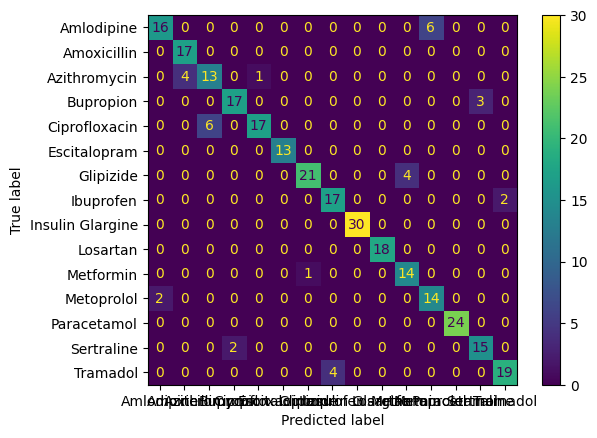

In [24]:
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

большинство наблюдений расположено на главной диагонали - высокая точность классификации для большинства лекарственных препаратов

значит модель в основном корректно предсказывает класс препарата

! Одно из **преимуществ** деревьев решений состоит в том, что эти деревья очень удобно интерпретировать. И для этого можно использовать множество атрибутов, которые появляются после обучения модели.

In [25]:
model.feature_importances_

array([0.03426976, 0.0097482 , 0.04601542, 0.02860654, 0.00670489,
       0.06737263, 0.07025799, 0.07822895, 0.07343593, 0.00153255,
       0.        , 0.        , 0.        , 0.        , 0.04137877,
       0.05261195, 0.02213171, 0.00528393, 0.0451442 , 0.03061914,
       0.01943957, 0.        , 0.02205064, 0.03429765, 0.01952842,
       0.02438481, 0.        , 0.06726525, 0.0242341 , 0.0180757 ,
       0.01506531, 0.02323018, 0.0253608 , 0.02315849, 0.02629582,
       0.01984083, 0.02442987, 0.        ])

видим важность отдельных признаков, эти значения перечислены здесь в том же порядке, что и наши признаки

Вспомним, как выглядят признаки

In [26]:
X.columns

Index(['Age', 'Dosage_mg', 'Treatment_Duration_days', 'Improvement_Score',
       'Gender_Male', 'Condition_Diabetes', 'Condition_Hypertension',
       'Condition_Infection', 'Condition_Pain Relief', 'Side_Effects_Allergy',
       'Side_Effects_Anxiety', 'Side_Effects_Back pain',
       'Side_Effects_Constipation', 'Side_Effects_Cough',
       'Side_Effects_Diarrhea', 'Side_Effects_Dizziness',
       'Side_Effects_Drowsiness', 'Side_Effects_Dry mouth',
       'Side_Effects_Fatigue', 'Side_Effects_Headache',
       'Side_Effects_Heartburn', 'Side_Effects_Injection site pain',
       'Side_Effects_Insomnia', 'Side_Effects_Joint pain',
       'Side_Effects_Liver issues', 'Side_Effects_Low blood sugar',
       'Side_Effects_Low sugar', 'Side_Effects_Nausea', 'Side_Effects_Rash',
       'Side_Effects_Skin rash', 'Side_Effects_Sleep issues',
       'Side_Effects_Slow heartbeat', 'Side_Effects_Stomach pain',
       'Side_Effects_Stomach upset', 'Side_Effects_Sweating',
       'Side_Effects_Sw

удобное представление в виде таблицы

In [29]:
pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Важность признаков']).sort_values('Важность признаков', ascending=False)

,Важность признаков
Condition_Infection,0.078229
Condition_Pain Relief,0.073436
Condition_Hypertension,0.070258
Condition_Diabetes,0.067373
Side_Effects_Nausea,0.067265
Side_Effects_Dizziness,0.052612
Treatment_Duration_days,0.046015
Side_Effects_Fatigue,0.045144
Side_Effects_Diarrhea,0.041379
Side_Effects_Joint pain,0.034298


Наиболее значимыми оказываются признаки, связанные с количеством симптомов и возрастом пациента.
Некоторые признаки могут не использоваться деревом вовсе.

## Визуализация дерева


https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

In [30]:
from sklearn.tree import plot_tree

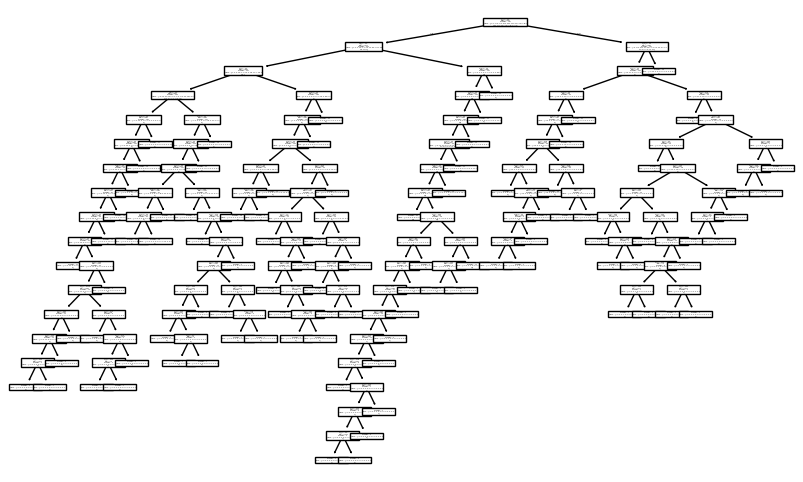

In [31]:
plt.figure(figsize=(10,6))
plot_tree(model); # model - модель деревьев решений, ; в конце чтобы оставить только визуальное дерево

каждый узел дерева соответствует проверке условия по одному признаку, а листовые узлы содержат итоговое решение — предсказанный класс препарата

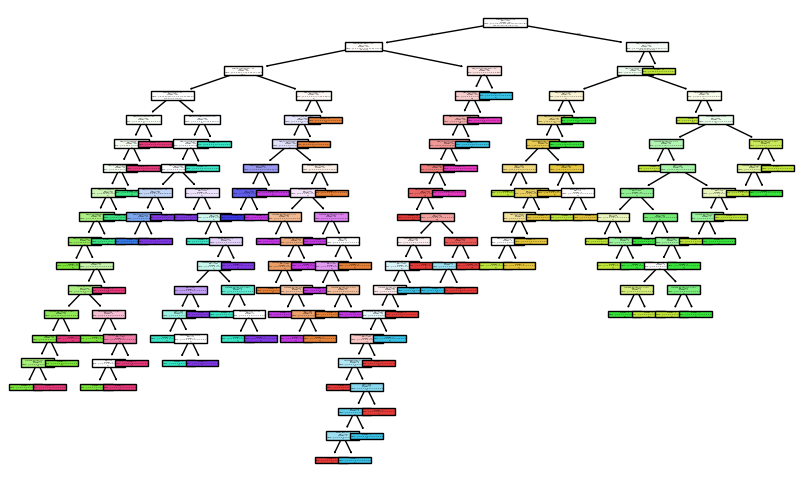

In [43]:
plt.figure(figsize=(10,6))
plot_tree(model, filled=True, feature_names=X.columns);

из-за отсутствия ограничений на глубину дерево получилось большим с большим числом внутренних узлов и листьев

это модель стремится максимально точно подстроиться под обучающие данные, что повышает точность, но етсь риск переобучения

Первая строка в узле дерев - условия разбиения в узле.
Вторая строка – это метрика Gini-Impurity.
Третья строка samples - число точек, которое пришло на вход в этот узел

In [33]:
len(X_train)

700

## Результаты модели

Чтобы поэкспериментировать с гиперпараметрами, создадим функцию, которая возвращает результаты классификации, а также рисует дерево.

Функция нужна для удобства, чтобы не копировать каждый раз одни и те же строчки кода.

In [34]:
def report_model(model):
    model_preds = model.predict(X_test) # это будет тот же самый тестовый набор,
    # что и раньше и это позволит нам сравнивать различные деревья между собой на одних и тех же данных.
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=X.columns); # визулизация дерева

                  precision    recall  f1-score   support

      Amlodipine       0.89      0.73      0.80        22
     Amoxicillin       0.81      1.00      0.89        17
    Azithromycin       0.68      0.72      0.70        18
       Bupropion       0.89      0.85      0.87        20
   Ciprofloxacin       0.94      0.74      0.83        23
    Escitalopram       1.00      1.00      1.00        13
       Glipizide       0.95      0.84      0.89        25
       Ibuprofen       0.81      0.89      0.85        19
Insulin Glargine       1.00      1.00      1.00        30
        Losartan       1.00      1.00      1.00        18
       Metformin       0.78      0.93      0.85        15
      Metoprolol       0.70      0.88      0.78        16
     Paracetamol       1.00      1.00      1.00        24
      Sertraline       0.83      0.88      0.86        17
        Tramadol       0.90      0.83      0.86        23

        accuracy                           0.88       300
       macro

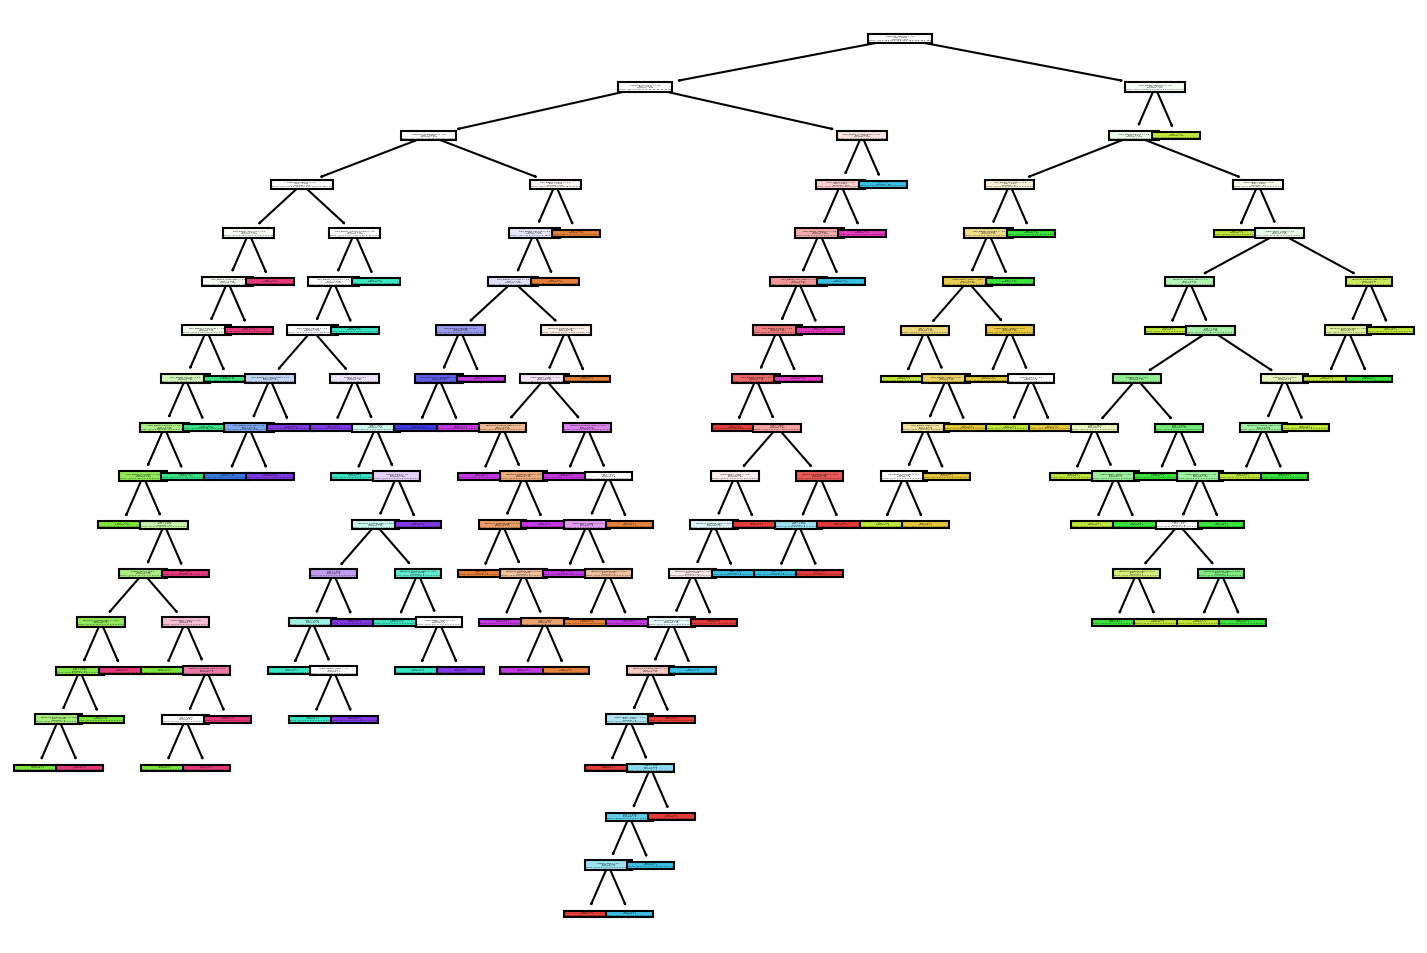

In [35]:
report_model(model)

Далее можем посмотреть на различные гиперпараметры и увидеть, как они влияют на результаты работы модели, а также на само дерево.

## Гиперпараметры

### Гиперпараметр "Max Depth" (максимальная глубина дерева)

In [54]:
#help(DecisionTreeClassifier) - можно посмотреть подробно, какие есть параметры

In [46]:
pruned_tree = DecisionTreeClassifier(max_depth=2) # ограничим глубину нашего дерева
pruned_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


                  precision    recall  f1-score   support

      Amlodipine       0.12      1.00      0.22        22
     Amoxicillin       0.00      0.00      0.00        17
    Azithromycin       1.00      0.22      0.36        18
       Bupropion       0.00      0.00      0.00        20
   Ciprofloxacin       0.43      1.00      0.60        23
    Escitalopram       0.00      0.00      0.00        13
       Glipizide       0.00      0.00      0.00        25
       Ibuprofen       0.00      0.00      0.00        19
Insulin Glargine       0.00      0.00      0.00        30
        Losartan       0.00      0.00      0.00        18
       Metformin       0.00      0.00      0.00        15
      Metoprolol       0.00      0.00      0.00        16
     Paracetamol       0.00      0.00      0.00        24
      Sertraline       0.00      0.00      0.00        17
        Tramadol       0.35      1.00      0.52        23

        accuracy                           0.24       300
       macro

/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


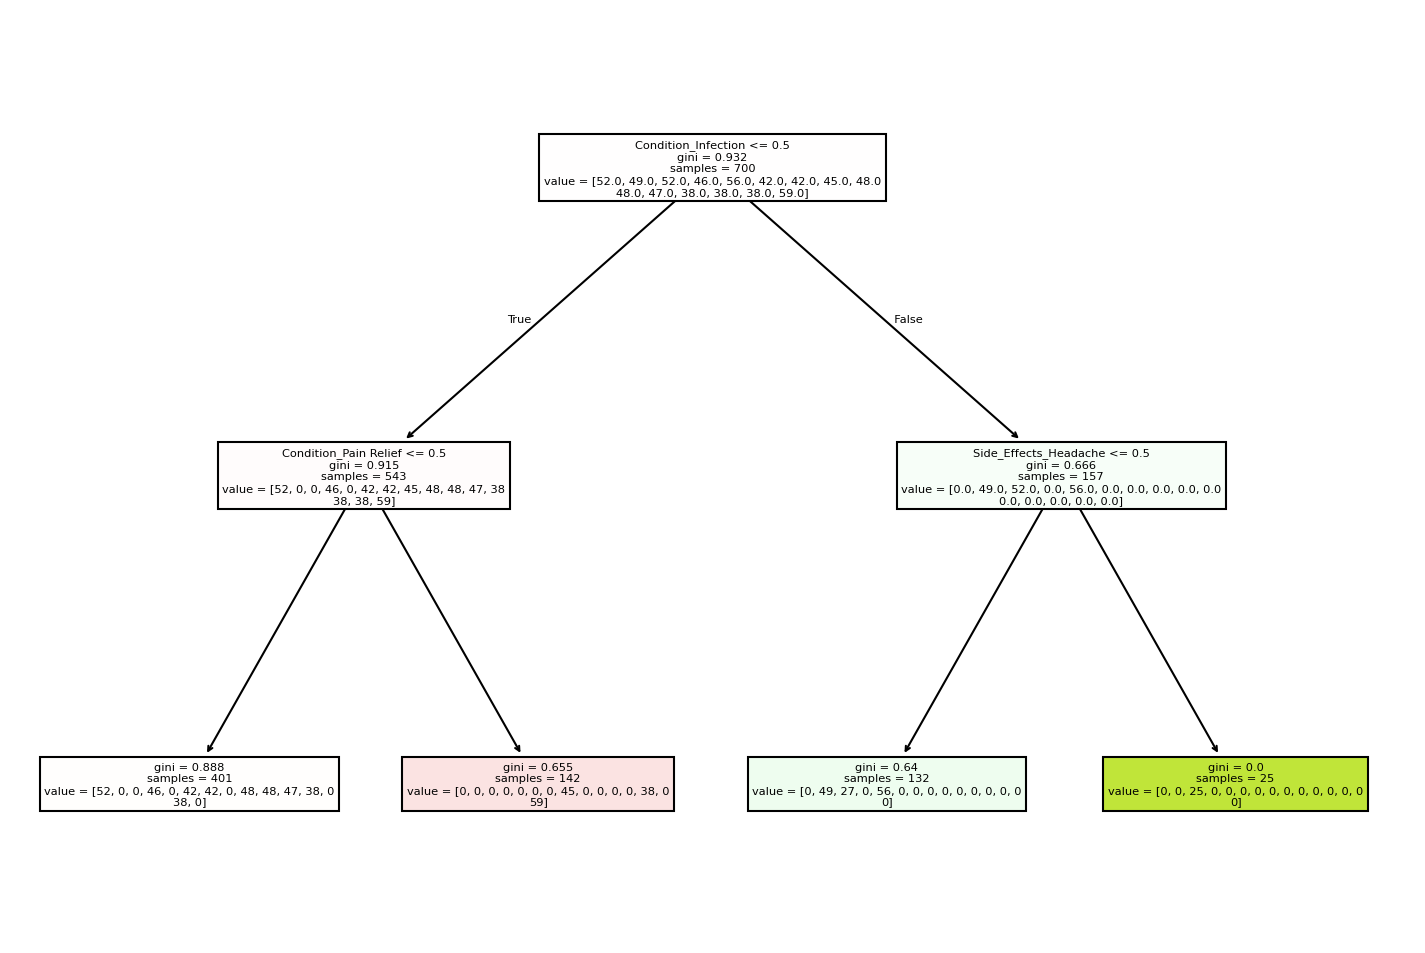

In [47]:
report_model(pruned_tree)

gini - мера неоднородности классов в узле. (0 - все объекты одного класса, ближе к 1 - классы сильно перемешаны)

в корне значение большое значит данные плохо разделен

samples = 700 - колво обучающих объектов, попавших в этот узел (в корневом узле вся обучающая выборка)

value - колво объектов каждого класса в узле, порядок значений соответствует порядку классов в model.classes_ (самое большое число будет предсказываемый класс в этом узле)

## Гиперпараметр "Max Leaf Nodes" (ограничить максимальное количество листовых узлов)

In [57]:
max_leaf_tree = DecisionTreeClassifier(max_leaf_nodes=5)
max_leaf_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                  precision    recall  f1-score   support

      Amlodipine       0.39      1.00      0.56        22
     Amoxicillin       0.00      0.00      0.00        17
    Azithromycin       0.00      0.00      0.00        18
       Bupropion       0.40      1.00      0.57        20
   Ciprofloxacin       0.40      1.00      0.57        23
    Escitalopram       0.00      0.00      0.00        13
       Glipizide       0.00      0.00      0.00        25
       Ibuprofen       0.00      0.00      0.00        19
Insulin Glargine       0.43      1.00      0.60        30
        Losartan       0.00      0.00      0.00        18
       Metformin       0.00      0.00      0.00        15
      Metoprolol       0.00      0.00      0.00        16
     Paracetamol       0.00      0.00      0.00        24
      Sertraline       0.00      0.00      0.00        17
        Tramadol       0.35      1.00      0.52        23

        accuracy                           0.39       300
       macro

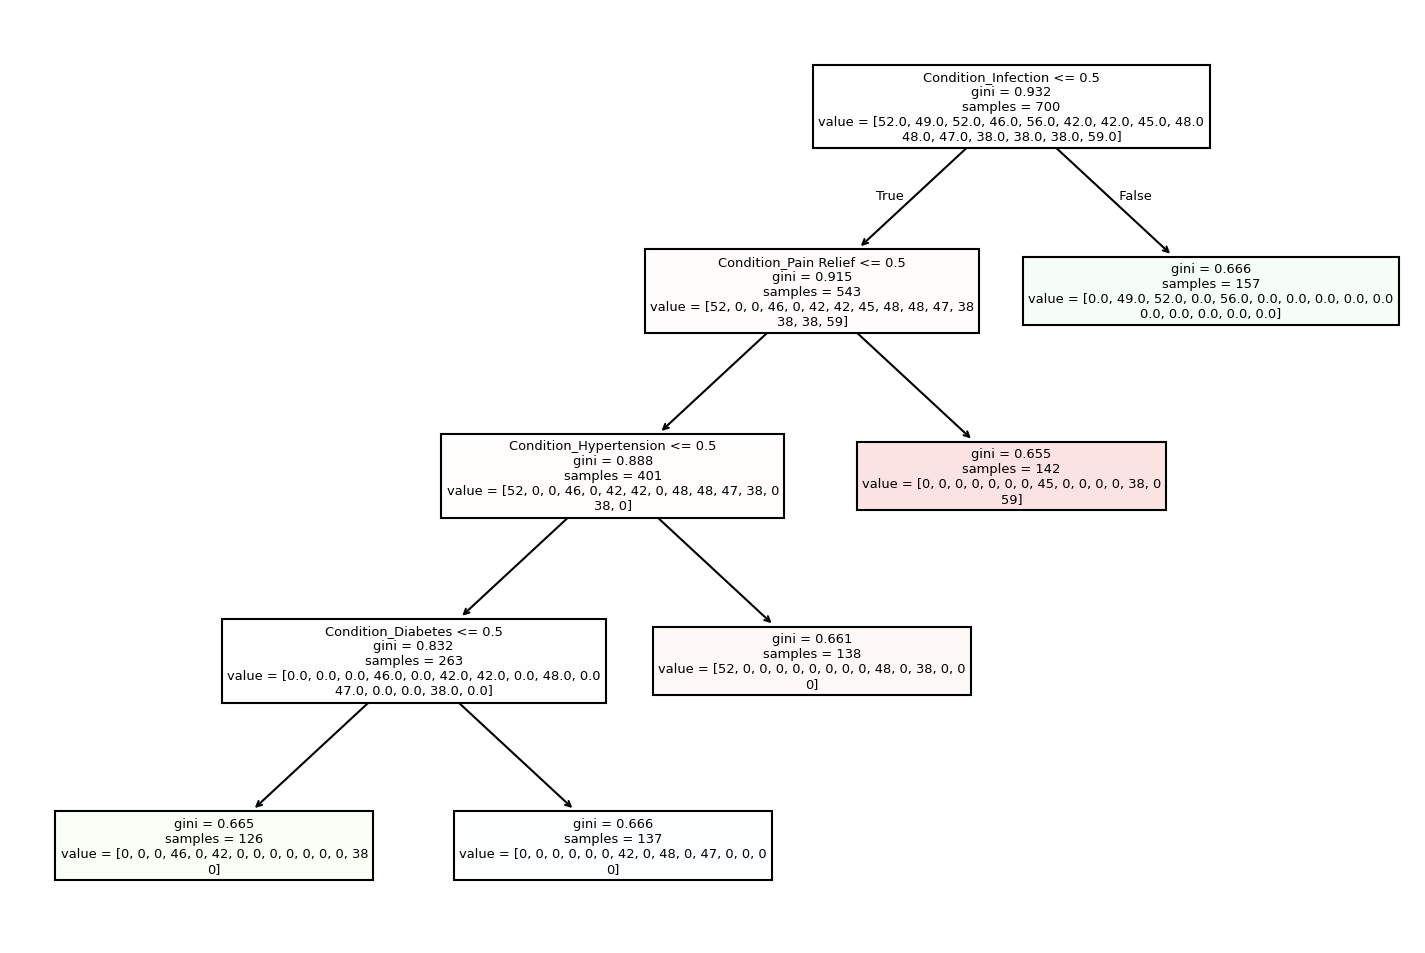

In [58]:
report_model(max_leaf_tree)

листовые узлы разбиваются: при каждом разбиении алгоритм выбираетто разбиение, которое дает наибольшее снижение gini по всему дереву

левая ветвь содержит большинство данных (543/ 157), более неоднородна, пожтому любое разбиение там
- затрагивает много объектов
- дает больший суммарный выигрыш по gini

даже если справа gini ниже, выигрыш от еее дальнейшего деления будет маленьким, потому что данных мало

## Гиперпараметр "Criterion"

указываем другую метрику, с помощью которой мы будем выполнять построение нашего дерева.

criterion{“gini”, “entropy”, “log_loss”}, default=”gini” The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

entropy (энтропия) — это мера неопределенности и беспорядка в узле дерева

низкая - в узле почти один класс, значии все понятно
высокая - классы сильно перемешаны, получается неопределенность

In [40]:
entropy_tree = DecisionTreeClassifier(criterion='entropy') # по умолчанию criterion gini
entropy_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


когда criterion='entropy' дерево выбирает разбиения, которые максимально уменьшают неопределенность классов

                  precision    recall  f1-score   support

      Amlodipine       0.89      0.77      0.83        22
     Amoxicillin       0.81      1.00      0.89        17
    Azithromycin       0.69      0.61      0.65        18
       Bupropion       0.94      0.85      0.89        20
   Ciprofloxacin       0.86      0.78      0.82        23
    Escitalopram       1.00      1.00      1.00        13
       Glipizide       0.95      0.84      0.89        25
       Ibuprofen       0.81      0.89      0.85        19
Insulin Glargine       1.00      1.00      1.00        30
        Losartan       1.00      1.00      1.00        18
       Metformin       0.78      0.93      0.85        15
      Metoprolol       0.74      0.88      0.80        16
     Paracetamol       1.00      1.00      1.00        24
      Sertraline       0.84      0.94      0.89        17
        Tramadol       0.90      0.83      0.86        23

        accuracy                           0.89       300
       macro

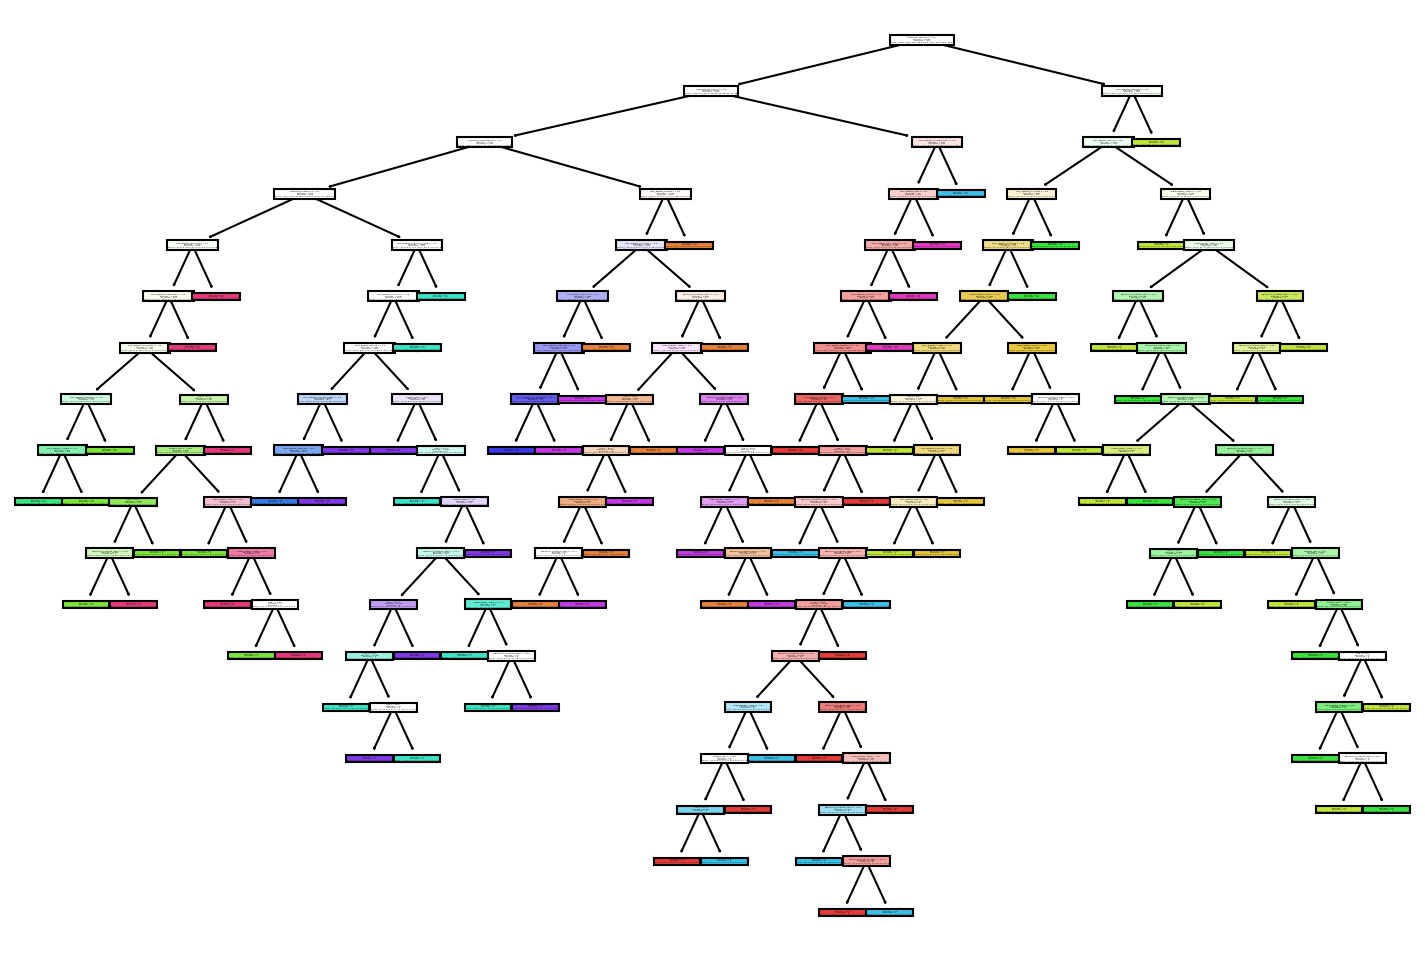

In [41]:
report_model(entropy_tree)

дерево оч похоже на наше первоначальное. метрики могут отличаться в зависимости от данных и по разному разбивать

**Для поиска оптимальных значений гиперпараметров (особенно при большом объёме данных) лучше всего выполнить кросс-валидацию и поиск по сетке grid-search.** 


# Проверка предсказания модели

прмер из датасета

P0004,32,Male,Diabetes,Glipizide,850,44,Low blood sugar,6.4

In [66]:
sample = pd.DataFrame([{
    'Patient_ID': 'P0004',
    'Age': 32,
    'Gender': 'Male',
    'Condition': 'Diabetes',
    'Drug_Name': 'Glipizide',
    'Dosage_mg': 850,
    'Treatment_Duration_days': 44,
    'Side_Effects': 'Low blood sugar',
    'Improvement_Score': 6.4
}])

    'Drug_Name': 'Glipizide', - фактический класс

In [69]:
sample_X = pd.get_dummies(sample.drop(['Drug_Name', 'Patient_ID'], axis=1),drop_first=True)
sample_X = sample_X.reindex(columns=X.columns, fill_value=0)

In [70]:
predicted_drug = model.predict(sample_X)
predicted_drug

array(['Bupropion'], dtype=object)

модель классифицировала как Bupropion, хотя на самом деле препарат Glipizide

такое расхождение объясняется тем, что дерево решений принимает решения на основе совокупности всех признаков, и отдельные комбинации значений могут приводить к выбору другого класса